In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings("ignore")


file_path = '/content/drive/MyDrive/Logistic_Regression/Admission_Predict.csv'
data = pd.read_csv(file_path)


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [4]:
display(data.head())

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [5]:
data.isnull().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


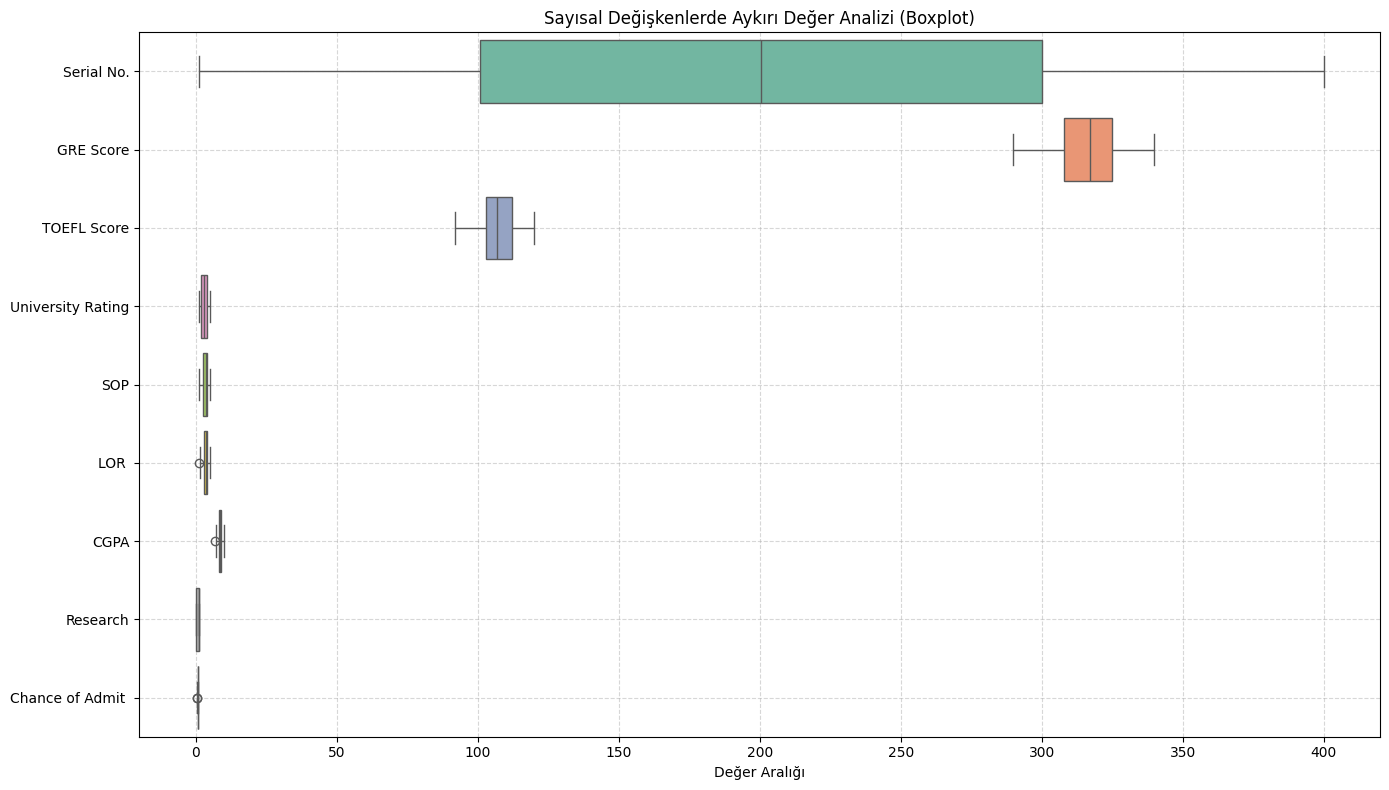

In [6]:
# Sayısal sütunları al
numeric_cols = data.select_dtypes(include="number").columns

# Plot için ayarlar
plt.figure(figsize=(14, 8))
data_to_plot = data[numeric_cols]

# Her bir sütun için boxplot çiz
sns.boxplot(data=data_to_plot, orient="h", palette="Set2", linewidth=1)

plt.title("Sayısal Değişkenlerde Aykırı Değer Analizi (Boxplot)")
plt.xlabel("Değer Aralığı")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


tüm özelliklerin aykırı değer grafiği.

In [7]:

from scipy import stats

# Örnek olarak CGPA sütununda aykırı değerleri kontrol edelim
z_scores = np.abs(stats.zscore(data["CGPA"]))

# Z-score > 3 olanları aykırı kabul edelim
threshold = 3
outliers_z = data[z_scores > threshold]

print("Z-Score yöntemiyle bulunan aykırı değer sayısı:", outliers_z.shape[0])
display(outliers_z)


Z-Score yöntemiyle bulunan aykırı değer sayısı: 1


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
58,59,300,99,1,3.0,2.0,6.8,1,0.36


aykırı değer sayısını gösteren kodumuz biraz aşağıda düzelttik bunları


In [8]:
# Hedef değişkeni 0 ve 1 olarak sınıflandıralım
data["Chance of Admit Binary"] = (data["Chance of Admit "] >= 0.8).astype(int)

# data = data.drop(columns=["Chance of Admit "]) #### aşağıda kullanacağım şeylerden dolayı drop etmekten vazgeçtim

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# v ye atadık bunları
V = add_constant(data[["GRE Score", "TOEFL Score", "University Rating", "SOP", "LOR ", "CGPA", "Research"]])

# VIF hesaplaması
vif_data = pd.DataFrame()
vif_data["Variable"] = V.columns
vif_data["VIF"] = [variance_inflation_factor(V.values, i) for i in range(V.shape[1])]

print(vif_data)


            Variable          VIF
0              const  1529.672661
1          GRE Score     4.615516
2        TOEFL Score     4.288959
3  University Rating     2.919606
4                SOP     3.075504
5               LOR      2.431258
6               CGPA     5.207403
7           Research     1.543312


In [10]:
X = data[["GRE Score", "TOEFL Score", "University Rating", "SOP", "CGPA", "Research"]]
y = data["Chance of Admit Binary"]

In [11]:
# **Aykırı Değer Analizi ve Temizleme (IQR Metodu)**

def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

for col in X:
    data = remove_outliers_iqr(data, col)


aykırı değerleri temizledik.

In [12]:

from scipy import stats

# Örnek olarak CGPA sütununda aykırı değerleri kontrol edelim
z_scores = np.abs(stats.zscore(data["CGPA"]))

# Z-score > 3 olanları aykırı kabul edelim
threshold = 3
outliers_z = data[z_scores > threshold]

print("Z-Score yöntemiyle bulunan aykırı değer sayısı:", outliers_z.shape[0])
display(outliers_z)


Z-Score yöntemiyle bulunan aykırı değer sayısı: 0


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit,Chance of Admit Binary


aykırı değer kontorlümüz

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# 2. Eğitim/test setine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
y_train.value_counts()

,count
Chance of Admit Binary,
0,221
1,99


smote yapmalı mıyız yapmamalı mıyız diye y_traindeki değerlere bakıyoruz

In [15]:
# **Sınıf Dağılımını Kontrol Etme (Öncesi)**
print("SMOTE öncesi sınıf dağılımı:", Counter(y_train))


SMOTE öncesi sınıf dağılımı: Counter({0: 221, 1: 99})


In [16]:
from imblearn.over_sampling import SMOTE
# **SMOTE ile Azınlık Sınıfları Artırma**
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)



# **Sınıf Dağılımını Kontrol Etme (Sonrası)**
print("SMOTE sonrası sınıf dağılımı:", Counter(y_train))

SMOTE sonrası sınıf dağılımı: Counter({1: 221, 0: 221})


smote yapmamız gerektiğini anladık ve smote işlemini standart scalerden önce yaptık


In [17]:




scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # sadece transform yapılır

scale zamanııııııııııı

In [18]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Modeli oluşturup eğitelim

model = LogisticRegression(max_iter=1000, tol=1e-4, solver='lbfgs', random_state=42)
#model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_scaled, y_train.values.ravel())

# Test verisi ile tahmin yapalım
y_pred = model.predict(X_test_scaled)
print(f"Model {model.n_iter_[0]} iterasyonda durdu. Çünkü hata değişimi belirlenen tol={model.tol} eşiğinin altına düştü.")





Model 12 iterasyonda durdu. Çünkü hata değişimi belirlenen tol=0.0001 eşiğinin altına düştü.


In [19]:
# Doğruluk oranı
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Doğruluk Oranı: {accuracy:.4f}")

# Sınıflandırma Raporu
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

# Karmaşıklık Matrisi (Confusion Matrix)
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nKarmaşıklık Matrisi:")
print(conf_matrix)




Model Doğruluk Oranı: 0.9375

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95        51
           1       0.88      0.97      0.92        29

    accuracy                           0.94        80
   macro avg       0.93      0.94      0.93        80
weighted avg       0.94      0.94      0.94        80


Karmaşıklık Matrisi:
[[47  4]
 [ 1 28]]


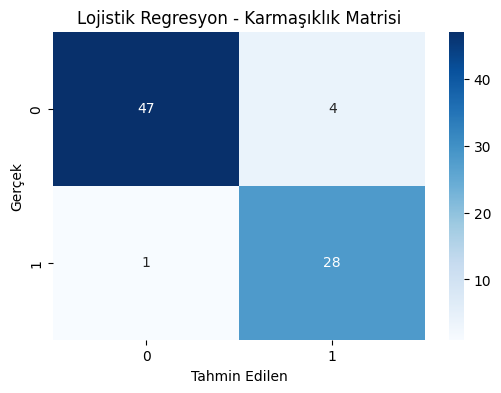

In [20]:
# Karmaşıklık matrisini görselleştirelim
import seaborn as sns

plt.figure(figsize=(6, 4))
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.title("Lojistik Regresyon - Karmaşıklık Matrisi")
plt.show()

In [21]:
y_train.value_counts()

,count
Chance of Admit Binary,
1,221
0,221


In [22]:
from sklearn.model_selection import train_test_split, GridSearchCV
# **Temel Lojistik Regresyon Modeli**
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500, class_weight='balanced')
log_reg.fit(X_train, y_train)

# **Tahmin ve Başarı Değerlendirme**
y_pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# **Hiperparametre Optimizasyonu (GridSearchCV ile)**
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
    'solver': ['lbfgs', 'saga'],  # Uygun çözücüler
    'max_iter': [200, 500, 1000]  # Daha uzun optimizasyon süreci
}

grid_search = GridSearchCV(LogisticRegression(multi_class='multinomial', max_iter=500, class_weight='balanced'), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# **En iyi modeli test etme**
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
best_accuracy = accuracy_score(y_test, y_pred_best)
best_report = classification_report(y_test, y_pred_best)

# **Sonuçları Yazdırma**
print("Base Model Accuracy:", accuracy)
print("Base Model Classification Report:\n", report)
print("\nOptimized Model Accuracy:", best_accuracy)
print("Optimized Model Best Params:", grid_search.best_params_)
print("\nOptimized Model Classification Report:\n", best_report)



Base Model Accuracy: 0.95
Base Model Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96        51
           1       0.90      0.97      0.93        29

    accuracy                           0.95        80
   macro avg       0.94      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80


Optimized Model Accuracy: 0.9375
Optimized Model Best Params: {'C': 10, 'max_iter': 200, 'solver': 'lbfgs'}

Optimized Model Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.92      0.95        51
           1       0.88      0.97      0.92        29

    accuracy                           0.94        80
   macro avg       0.93      0.94      0.93        80
weighted avg       0.94      0.94      0.94        80



 multinomial ve lbfgs çözücüsü kullanılarak temel bir model eğittik. Ardından bu modelin doğruluk ve sınıf bazlı performans metriklerini hesapladık. Daha sonra GridSearchCV kullanıp performansı iyileştirmeye çalıştık. En iyi   parametreleri gridsearch ile seçip test verisi üzerinde değerlendirdik

 lbfgs nin daha fazla verilerin olduğu datasetlerde kullanıldığını biliyorum ama denemek istedim


In [23]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# **Temel Lojistik Regresyon Modeli**
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500, class_weight='balanced')
log_reg.fit(X_train, y_train)

# **Tahmin ve Başarı Değerlendirme**
y_pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# **Hiperparametre Optimizasyonu (RandomizedSearchCV ile)**
param_dist = {
    'C': np.logspace(-3, 2, 6),  # Regularization strength (logarithmic aralık)
    'solver': ['lbfgs', 'saga'],  # Uygun çözücüler
    'max_iter': [200, 500, 1000],  # Daha uzun optimizasyon süreci
}

random_search = RandomizedSearchCV(LogisticRegression(multi_class='multinomial', max_iter=500, class_weight='balanced'), param_distributions=param_dist, n_iter=50, cv=5, scoring='accuracy', random_state=42)
random_search.fit(X_train, y_train)

# **En iyi modeli test etme**
best_modell = random_search.best_estimator_
y_pred_best = best_modell.predict(X_test)
best_accuracyy = accuracy_score(y_test, y_pred_best)
best_reportt = classification_report(y_test, y_pred_best)


# **Sonuçları Yazdırma**
print("Base Model Accuracy:", accuracy)
print("Base Model Classification Report:\n", report)
print("\nOptimized Model Accuracy:", best_accuracyy)
print("Optimized Model Best Params:", random_search.best_params_)
print("\nOptimized Model Classification Report:\n", best_reportt)


Base Model Accuracy: 0.95
Base Model Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96        51
           1       0.90      0.97      0.93        29

    accuracy                           0.95        80
   macro avg       0.94      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80


Optimized Model Accuracy: 0.9375
Optimized Model Best Params: {'solver': 'lbfgs', 'max_iter': 200, 'C': np.float64(10.0)}

Optimized Model Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.92      0.95        51
           1       0.88      0.97      0.92        29

    accuracy                           0.94        80
   macro avg       0.93      0.94      0.93        80
weighted avg       0.94      0.94      0.94        80



optimizasyonu bu sefer randomizesearch kullanarak gerçekleştirdik. esktradan model, max_iter 500 olduğu için 500 adım boyunca öğrenmeye çalıştı.

n_iter=50 olduğu için de 50 farklı parametre kombinasyonu denendi ve her biri için model eğitildi.

sonuç grid search ile aynı geldi

In [24]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from scipy.stats import uniform


# Modeli değerlendirmek için bir fonksiyon
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    return accuracy, roc_auc, confusion_matrix(y_test, y_pred), classification_report(y_test, y_pred)

# **Varsayılan Lojistik Regresyon Modeli**
base_model = LogisticRegression(solver='liblinear', class_weight='balanced')  # class_weight='balanced' dengeli sınıf dağılımı için
base_model.fit(X_train, y_train)
base_accuracy, base_roc_auc, base_conf_matrix, base_class_report = evaluate_model(base_model, X_test, y_test)

# **GridSearchCV ile Hiperparametre Optimizasyonu**
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Düzenleme gücü (regularization strength)
    'penalty': ['l1', 'l2']  # Ceza fonksiyonları
}
grid_search = GridSearchCV(base_model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
best_grid_model = grid_search.best_estimator_
grid_accuracy, grid_roc_auc, grid_conf_matrix, grid_class_report = evaluate_model(best_grid_model, X_test, y_test)

# **RandomizedSearchCV ile Hiperparametre Optimizasyonu**
param_dist = {
    'C': uniform(0.001, 10),  # Düzenleme gücü için geniş bir dağılım
    'penalty': ['l1', 'l2']  # Ceza fonksiyonları
}
random_search = RandomizedSearchCV(base_model, param_dist, n_iter=10, cv=5, scoring='accuracy', random_state=42)
random_search.fit(X_train, y_train)
best_random_model = random_search.best_estimator_
random_accuracy, random_roc_auc, random_conf_matrix, random_class_report = evaluate_model(best_random_model, X_test, y_test)

# **Sonuçları Tablo Olarak Hazırlama**
results_df = pd.DataFrame({
    "Method": ["Base Model", "GridSearch", "RandomizedSearch"],
    "Best Params": ["Default", grid_search.best_params_, random_search.best_params_],
    "Accuracy": [base_accuracy, grid_accuracy, random_accuracy],
    "ROC-AUC Score": [base_roc_auc, grid_roc_auc, random_roc_auc]
})

# **Sonuçları Yazdırma**
print("Lojistik Regresyon Model Karşılaştırması:")
print(results_df)

# **Confusion Matrix ve Classification Report Yazdırma**
print("\nBase Model Confusion Matrix:\n", base_conf_matrix)
print("\nBase Model Classification Report:\n", base_class_report)

print("\nGridSearch Confusion Matrix:\n", grid_conf_matrix)
print("\nGridSearch Classification Report:\n", grid_class_report)

print("\nRandomizedSearch Confusion Matrix:\n", random_conf_matrix)
print("\nRandomizedSearch Classification Report:\n", random_class_report)




Lojistik Regresyon Model Karşılaştırması:
             Method                                Best Params  Accuracy  \
0        Base Model                                    Default    0.8625   
1        GridSearch                 {'C': 10, 'penalty': 'l1'}    0.9500   
2  RandomizedSearch  {'C': 3.746401188473625, 'penalty': 'l1'}    0.9625   

   ROC-AUC Score  
0       0.981068  
1       0.994591  
2       0.994591  

Base Model Confusion Matrix:
 [[42  9]
 [ 2 27]]

Base Model Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.82      0.88        51
           1       0.75      0.93      0.83        29

    accuracy                           0.86        80
   macro avg       0.85      0.88      0.86        80
weighted avg       0.88      0.86      0.86        80


GridSearch Confusion Matrix:
 [[48  3]
 [ 1 28]]

GridSearch Classification Report:
               precision    recall  f1-score   support

           0       0.98

 Bu kodda diğerlerinden farklı olarak liblinear çözümleyicisi kullanılıyor. Bu, daha küçük veri setleri ve L1 ceza fonksiyonu için ideal. ayrıca randomizedsearch ve gridsearch birleşik bir şekilde sonuç veriyor. randomizedsearch ın değerleri çok doğru ve yerinde gözüküyor. aşağıda, görselleştirmeyle daha iyi görebilmeyi sağladım


liblinear → Küçük veri setleri için idealdir, L1 ve L2 desteği vardır.

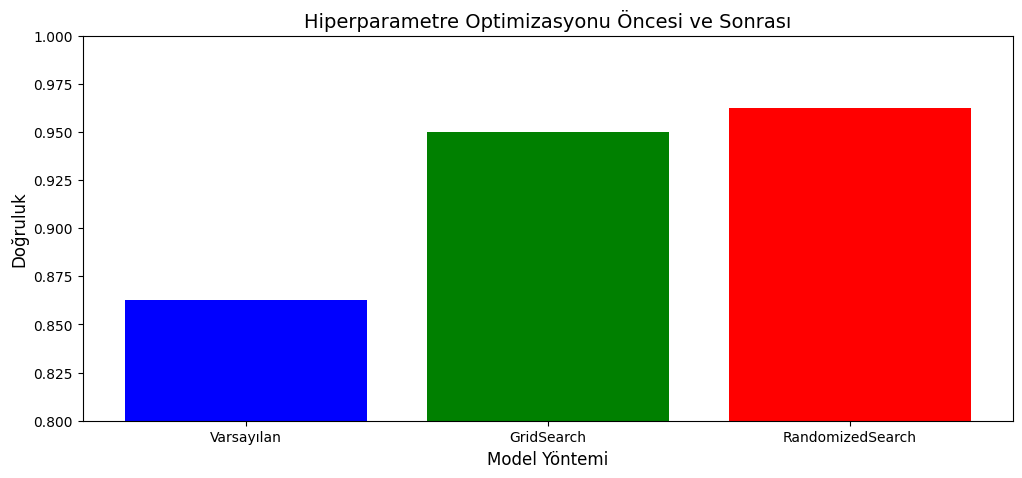

In [25]:
import matplotlib.pyplot as plt

# Hiperparametre optimizasyonu sonrası doğrulukların görselleştirilmesi
plt.figure(figsize=(12, 5))

# Doğrulukları ve renkleri belirliyoruz
accuracies = [base_accuracy, grid_accuracy, random_accuracy]
models = ['Varsayılan', 'GridSearch', 'RandomizedSearch']
colors = ['blue', 'green', 'red']

# Bar grafiğini çiziyoruz
plt.bar(models, accuracies, color=colors)

# Y ekseni sınırlarını ve etiketlerini belirliyoruz
plt.ylim(0.8, 1.0)
plt.ylabel('Doğruluk', fontsize=12)

# Başlık ve etiketleri ekliyoruz
plt.title('Hiperparametre Optimizasyonu Öncesi ve Sonrası', fontsize=14)
plt.xlabel('Model Yöntemi', fontsize=12)

# Grafiği gösteriyoruz
plt.show()


gridsearch ve randomsearch varsayılana göre çok daha doğru sonuç vermekte. randomizedsearch hepsine göre daha doğru sonuçlar veriyor.

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Precision, Recall, F1 karşılaştırma tablosu için fonksiyon
def get_classification_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)

    # Çok sınıflı sınıflandırma için average='macro' parametresi
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='macro'),  # average='macro' tüm sınıflar için hesaplar
        "Recall": recall_score(y_test, y_pred, average='macro'),        # average='macro' tüm sınıflar için hesaplar
        "F1 Score": f1_score(y_test, y_pred, average='macro')           # average='macro' tüm sınıflar için hesaplar
    }
    return metrics

# Modellerin karşılaştırılması
models = {
    "Base Model": base_model,
    "GridSearch": best_grid_model,
    "RandomizedSearch": best_random_model
}

metrics_data = []

for name, mdl in models.items():
    metrics = get_classification_metrics(mdl, X_test, y_test)
    metrics["Model"] = name
    metrics_data.append(metrics)

# Sonuçları tablo haline getir
metrics_df = pd.DataFrame(metrics_data).set_index("Model")

# Yazdır
print("\n🧪 Lojistik Regresyon Metrik Karşılaştırması özeti (Accuracy, Precision, Recall, F1):")
print(metrics_df)



🧪 Lojistik Regresyon Metrik Karşılaştırması özeti (Accuracy, Precision, Recall, F1):
                  Accuracy  Precision    Recall  F1 Score
Model                                                    
Base Model          0.8625   0.852273  0.877282  0.857490
GridSearch          0.9500   0.941409  0.953347  0.946667
RandomizedSearch    0.9625   0.953125  0.970588  0.960258


tek kısa bir yerde göstermek için ikinci bir özet yazdırdım. görüldüğü üzere randomizedsearch is the best

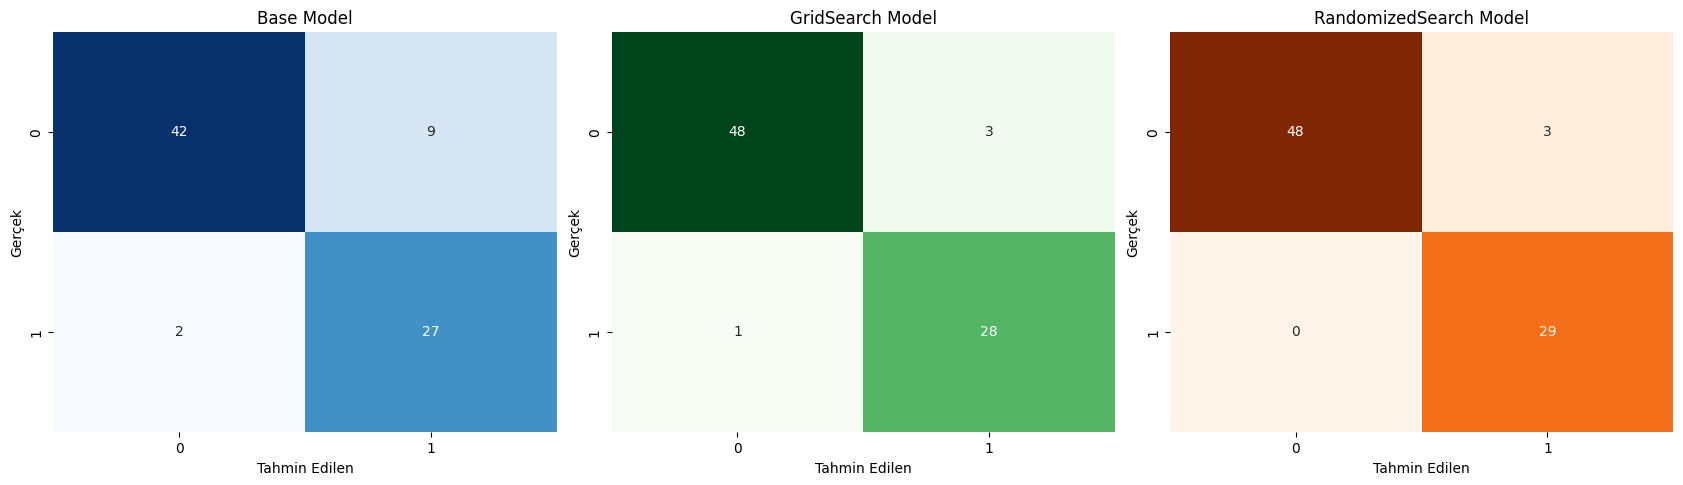

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tüm karmaşıklık matrislerini bir arada çiz
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Base Model
sns.heatmap(base_conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title("Base Model")
axes[0].set_xlabel("Tahmin Edilen")
axes[0].set_ylabel("Gerçek")

# GridSearch Model
sns.heatmap(grid_conf_matrix, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title("GridSearch Model")
axes[1].set_xlabel("Tahmin Edilen")
axes[1].set_ylabel("Gerçek")

# RandomizedSearch Model
sns.heatmap(random_conf_matrix, annot=True, fmt='d', cmap='Oranges', ax=axes[2], cbar=False)
axes[2].set_title("RandomizedSearch Model")
axes[2].set_xlabel("Tahmin Edilen")
axes[2].set_ylabel("Gerçek")

# Daha iyi yerleşim için
plt.tight_layout()
plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1)

plt.show()


gördüğümüz üzere bu görselleştirmede randomizedsearch da true positif değerimiz daha fazla çıkmış. en iyi sonuç randomizedsearch'da ve bu yöntem doğruluk açısından bu veri setinde bize yeterli.

GridSearchCV: Tüm kombinasyonları dener, en iyi sonucu garanti eder ancak maliyeti yüksektir

RandomizedSearchCV: Rastgele örneklem alarak işlem süresini azaltır ancak en iyi sonucu garanti etmez.









daha iyi anlamak için bu tabloyu projeme de eklemek istedim.

| **Parametre**      | **Ne İşe Yarar?** |
|--------------------|------------------|
| **C**             | Regularization (aşırı öğrenmeyi engeller) |
| **penalty**       | L1 veya L2 cezası ile model katsayılarını düzenler |
| **solver**        | Modelin optimizasyonunu belirler |
| **max_iter**      | Maksimum iterasyon sayısını belirler |
| **fit_intercept** | Modelin sabit bir bias ekleyip eklemeyeceğini belirler |
| **class_weight**  | Dengesiz veri setlerinde sınıf ağırlıklarını ayarlar |
| **warm_start**    | Önceki eğitimi devam ettirerek öğrenmeye devam eder |


liblinear → Küçük veri setleri için idealdir, L1 ve L2 desteği vardır.

lbfgs → Büyük veri setleri için uygundur, yalnızca L2 destekler.

saga → Büyük ölçekli verilerde kullanılır, L1, L2 ve elasticnet destekler.

newton-cg → Büyük veri setleri için uygundur, yalnızca L2 destekler.



*   Bu projede önceki projeye göre ekstradan Smote ve ayrık değer analizi-düzeltimi eklendi. İlk baştaki yorumlamalar öncekinde olduğu için tekrar yapılmadı ancak yeni eklenen her şey yorumlandı.

kendime not:

SMOTE, veri dengesizliğini giderir ve modelin daha adil öğrenmesini sağlar.
Özellikle azınlık sınıfların tahmin başarısını artırır.
Gerçek dünya verilerinde sıkça kullanılan bir tekniktir.






madde3: Modeli iyileştirmek için başka yöntemler gerekli mi?

 1. daha fazla çzellik mühendisliği yapılabilir
 2. Random Forest gibi farklı modeller denenebilir
 3. cross-validation sayısı artırılarak daha sağlam sonuçlar elde edilebilir.
 4. daha dikkatli Veri Temizliği ve Ön İşleme yapılabilir.